In [61]:
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt 
import numpy as np 
import os
from sklearn.preprocessing import StandardScaler
from math import sqrt
from mpl_toolkits.mplot3d import Axes3D

In [230]:
def sigmoid(z):
        return 1 / (1 + np.exp(-z))

class MyLogisticRegressionMultiLabel: 
    def __init__(self, learning_rate: float = 0.001, no_epochs: int = 1000):
        self.intercept_ = []
        self.coef_ = []
        self.__learning_rate = learning_rate
        self.__no_epochs = no_epochs
        
    
    def fit(self, x, y):
        self.coef_ = []
        self.intercept_ = []
        labels = list(sorted(set(y)))
        for label in labels:
            coef = [random.random() for _ in range(len(x[0]) + 1)]
            for _ in range(self.__no_epochs):
                for i in range(len(x)):
                    #calculez eroarea intre ce a prezis modelul si outputul real
                    y_computed = sigmoid(self.eval(x[i], coef))
                    crt_error = y_computed -( 1 if y[i] == label else 0)
                    #ajustez coeficientii pentru a reduce eroarea
                    for j in range(1, len(coef)):
                        coef[j] -= self.__learning_rate * crt_error * x[i][j - 1]
                    coef[0] -= self.__learning_rate * crt_error * 1
            self.intercept_.append(coef[0])
            self.coef_.append(coef[1:])

    def score(self, x_test, y_test):
        predictions = self.predict(x_test)
        correct_predictions = sum(1 for pred, true in zip(predictions, y_test) if pred == true)
        total_samples = len(y_test)
        accuracy = correct_predictions / total_samples

        return accuracy
    
    def eval(self, xi: list, coef: list):
        #suma ponderata + bias
        yi = coef[0]
        for j in range(1,len(xi)):
            yi += coef[j] * xi[j-1]
        return yi

    def predict_one_sample(self, sample_features: list):
        predictions = []
        #Pentru fiecare clasă, calculezi probabilitatea ca eșantionul să aparțină acelei clase.
        for intercept, coefficient in zip(self.intercept_, self.coef_):
            computed_value = self.eval(sample_features, coefficient)+intercept
            predictions.append(sigmoid(computed_value))
        #Returnezi indexul clasei cu cea mai mare probabilitate
        return predictions.index(max(predictions))


    def predict(self, in_test: list):
        computed_labels = [self.predict_one_sample(sample) for sample in in_test]
        return computed_labels

In [231]:
def loadDataMoreInputs(fileName, inputVariabNames, outputVariabName):
    def transform(output):
        if output == 'Iris-setosa':
            return 0
        elif output == 'Iris-versicolor':
            return 1
        elif output == 'Iris-virginica':
            return 2
      
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariables = [dataNames.index(var) for var in inputVariabNames]
    inputs = [[float(data[i][j]) for j in selectedVariables] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [transform(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs, outputs

In [232]:
def plot3Ddata1(x1Train, x2Train, yTrain, x1Model=None, x2Model=None, yModel=None, x1Test=None, x2Test=None, yTest=None, title=None, classNames=None):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    ax = plt.axes(projection='3d')
    handles = []
    labels = []

    # Train data, cu nume de clasă din argument
    if x1Train is not None:
        classes = sorted(set(yTrain))
        color_map = {0: 'g', 1: 'r', 2: 'b'}
        for cls in classes:
            mask = [val == cls for val in yTrain]
            train_plot = ax.scatter(
                [x for x, m in zip(x1Train, mask) if m],
                [x for x, m in zip(x2Train, mask) if m],
                [x for x, m in zip(yTrain, mask) if m],
                c=color_map.get(cls, 'gray'),
                marker='o'
            )
            handles.append(train_plot)
            # Dacă există classNames și are destul elemente, îl folosim
            if classNames is not None and cls < len(classNames):
                labels.append(f'Train data: {classNames[cls]}')
            else:
                labels.append(f'Train data: clasa {cls}')

    # Model data
    if x1Model:
        model_plot = ax.scatter(x1Model, x2Model, yModel, c='pink', marker='o')
        handles.append(model_plot)
        labels.append('Learnt model')

    # Test data
    if x1Test :
        test_plot = ax.scatter(x1Test, x2Test, yTest, c='black', marker='^')
        handles.append(test_plot)
        labels.append('Test data')

    plt.title(title)

    if handles:
        ax.legend(handles, labels)

    plt.show()



In [233]:
def plotHist(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[[5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2], [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2]]


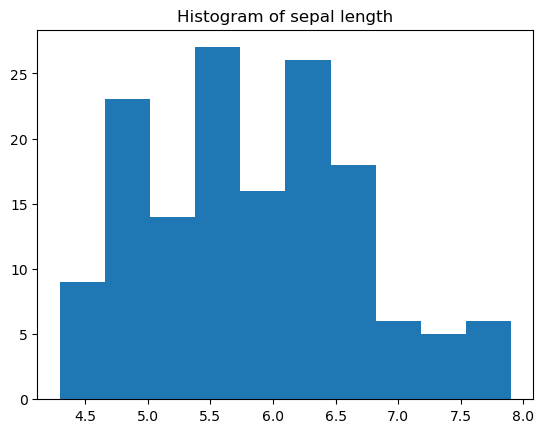

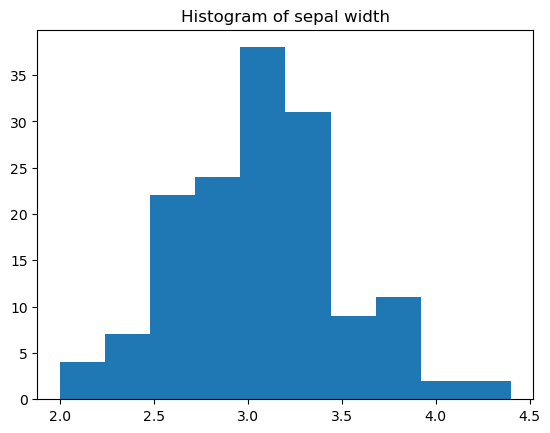

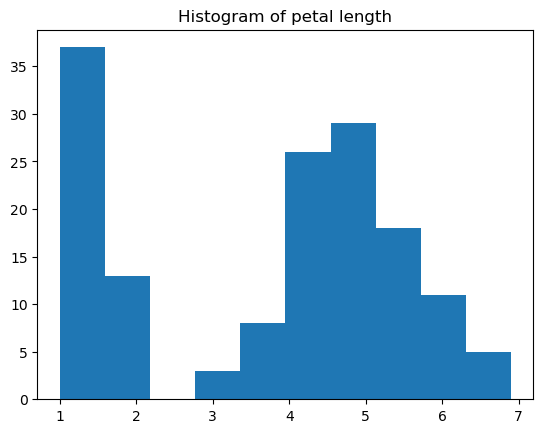

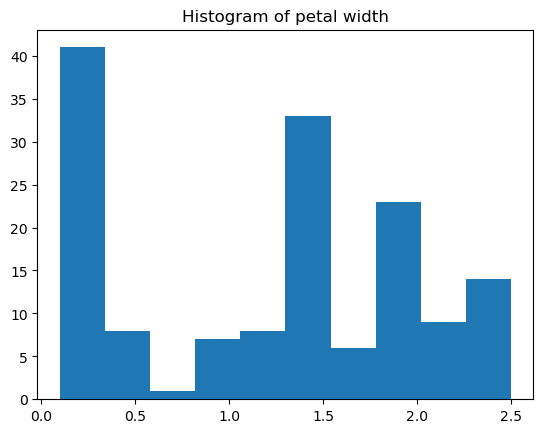

In [234]:
crtDir =  os.getcwd()
filePath = 'iris.csv'

inputs, outputs = loadDataMoreInputs(filePath, ['sepal length', 'sepal width', 'petal length', 'petal width'], 'class')
print(outputs)
print(inputs[:5])

feature1 = [ex[0] for ex in inputs]
feature2 = [ex[1] for ex in inputs]
feature3 = [ex[2] for ex in inputs]
feature4 = [ex[3] for ex in inputs]

plotHist(feature1,"sepal length")
plotHist(feature2, "sepal width")
plotHist(feature3, "petal length")
plotHist(feature4, "petal width")

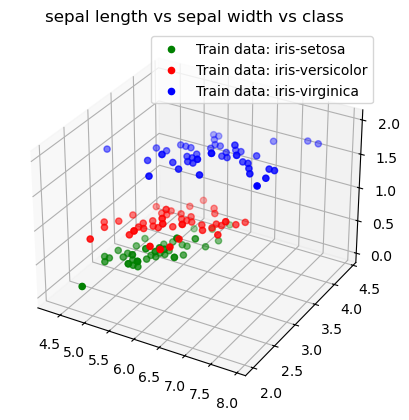

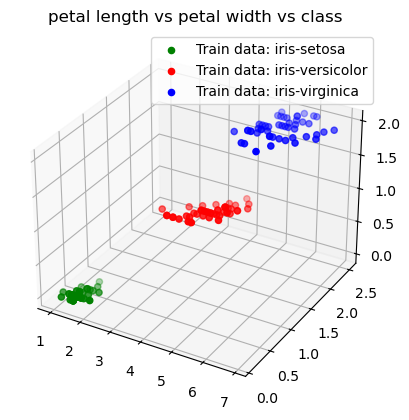

In [235]:
plot3Ddata1(feature1, feature2, outputs, title='sepal length vs sepal width vs class',classNames=["iris-setosa","iris-versicolor","iris-virginica"])
plot3Ddata1(feature3, feature4, outputs, title='petal length vs petal width vs class',classNames=["iris-setosa","iris-versicolor","iris-virginica"])

In [236]:
def normalisation(train_data, test_data):
    train_data = [list(np.ravel(d)) for d in train_data]
    test_data = [list(np.ravel(d)) for d in test_data]
    scaler = StandardScaler()
    scaler.fit(train_data)
    normalisedTrainData = scaler.transform(train_data)
    normalisedTestData = scaler.transform(test_data)
    return normalisedTrainData, normalisedTestData


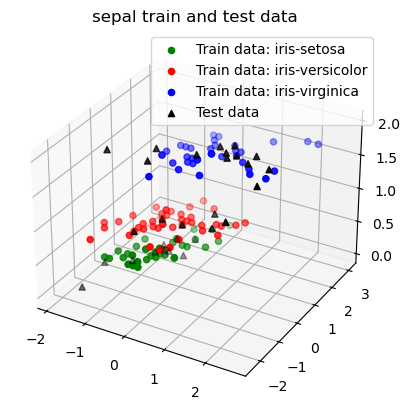

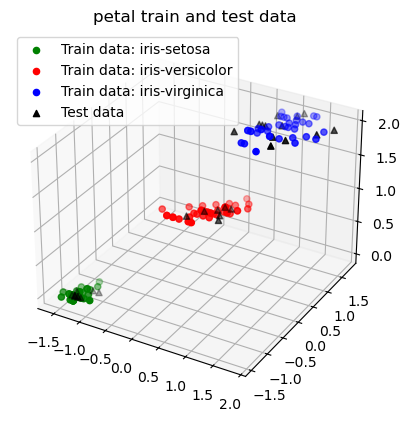

In [237]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

trainInputs,testInputs=normalisation(trainInputs,testInputs)


feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]
feature3train = [ex[2] for ex in trainInputs]
feature4train = [ex[3] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]
feature3test = [ex[2] for ex in testInputs]
feature4test = [ex[3] for ex in testInputs]

plot3Ddata1(feature1train, feature2train, trainOutputs, None, None, None, feature1test, feature2test, testOutputs, "sepal train and test data",classNames=["iris-setosa","iris-versicolor","iris-virginica"])
plot3Ddata1(feature3train, feature4train, trainOutputs, None, None, None, feature3test, feature4test, testOutputs, "petal train and test data",classNames=["iris-setosa","iris-versicolor","iris-virginica"])

In [238]:
import random
from math import exp
model = MyLogisticRegressionMultiLabel(learning_rate=0.01, no_epochs=1000)
model.fit(trainInputs, trainOutputs)


accuracy = model.score(testInputs, testOutputs)
print("Accuracy:", accuracy)

w0 = model.intercept_[0]
w1, w2, w3, w4 = model.coef_[0][0], model.coef_[0][1], model.coef_[0][2], model.coef_[0][3]


print("Model coefficients:")
print("f(x) =  1/ 1+ e^-z... z= ", w0, ' + ', w1, ' * x1 + \n\t\t\t', w2, ' * x2' , w3, ' * x4', w4, ' * x4')

Accuracy: 0.4
Model coefficients:
f(x) =  1/ 1+ e^-z... z=  -3.682619760471881  +  -2.380644442678341  * x1 + 
			 3.443639497231768  * x2 -4.824673320409064  * x4 -5.325994564842513  * x4


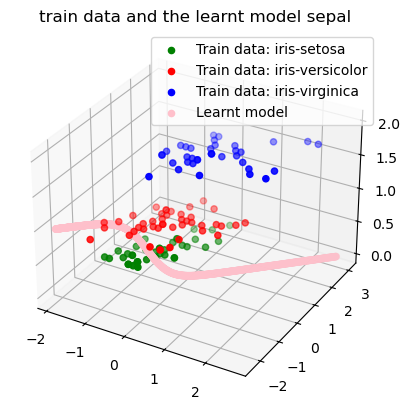

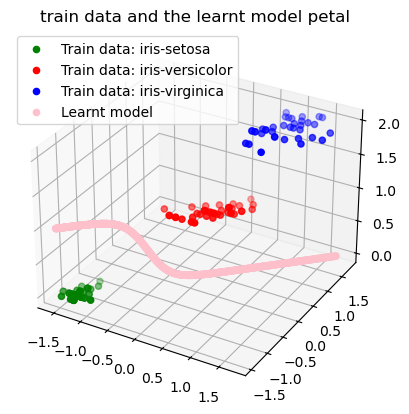

In [239]:
import numpy as np
from statistics import mean
trainInputs = np.array(trainInputs)
noOfPoints = 1000
xref1 = []
val = min(trainInputs[:, 0])
step1 = (max(trainInputs[:, 0]) - min(trainInputs[:, 0])) / noOfPoints
for _ in range(noOfPoints):
    xref1.append(val)
    val += step1

xref2 = []
val = min(trainInputs[:, 1])
step2 = (max(trainInputs[:, 1]) - min(trainInputs[:, 1])) / noOfPoints
for _ in range(noOfPoints):
    xref2.append(val)
    val += step2

xref3 = []
val = min(trainInputs[:, 2])
step3 = (max(trainInputs[:, 2]) - min(trainInputs[:, 2])) / noOfPoints
for _ in range(noOfPoints):
    xref3.append(val)
    val += step3

xref4 = []
val = min(trainInputs[:, 3])
step4 = (max(trainInputs[:, 3]) - min(trainInputs[:, 3])) / noOfPoints
for _ in range(noOfPoints):
    xref4.append(val)
    val += step4

yref = [1 / (1 + np.exp(-(w0 + w1 * el1 + w2 * el2 + w3 * el3 + w4 * el4))) for el1, el2, el3, el4 in zip(xref1, xref2, xref3, xref4)]
plot3Ddata1(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model sepal',classNames=["iris-setosa","iris-versicolor","iris-virginica"])
plot3Ddata1(feature3train, feature4train, trainOutputs, xref3, xref4, yref, [], [], [], 'train data and the learnt model petal',classNames=["iris-setosa","iris-versicolor","iris-virginica"])

In [240]:
computedTestOutputs = model.predict(testInputs)
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print('prediction error (manual): ', error)

error = 1 - accuracy

print('prediction error (tool):   ', error)

ec = 1 / (1 + np.exp(-(w0 + w1 * 5.35 + w2 * 3.85 + w3 * 1.25 + w4 * 0.4)))
#ec = ec[0]
print("Rez ec", ec)
if ec >=0 and ec < 0.33:
    print("Iris-setosa")
elif ec >= 0.33 and ec < 0.66:
    print("Iris-versicolor")
else:
    print("Iris-virginica")

prediction error (manual):  0.7
prediction error (tool):    0.6
Rez ec 1.2099976579320248e-05
Iris-setosa


In [ ]:
CU TOOL

In [159]:
crtDir =  os.getcwd()
filePath =  'iris (1).csv'

inputs, outputs = loadDataMoreInputs(filePath, ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth'], 'Class')

feature1 = [ex[0] for ex in inputs]
feature2 = [ex[1] for ex in inputs]
feature3 = [ex[2] for ex in inputs]
feature4 = [ex[3] for ex in inputs]


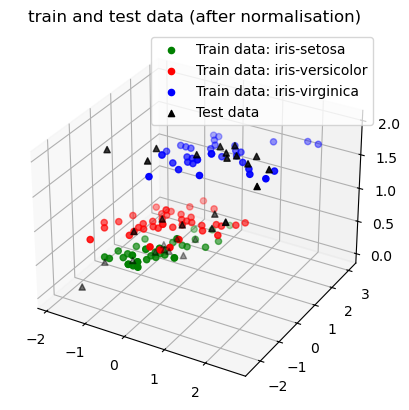

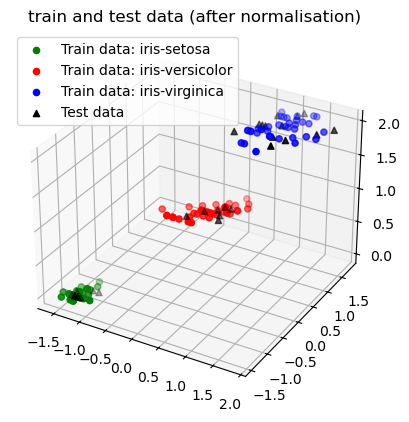

In [174]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]



trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

trainInputs,testInputs=normalisation(trainInputs,testInputs)

feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]
feature3train = [ex[2] for ex in trainInputs]
feature4train = [ex[3] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]
feature3test = [ex[2] for ex in testInputs]
feature4test = [ex[3] for ex in testInputs]

plot3Ddata1(feature1train, feature2train, trainOutputs, None, None, None, feature1test, feature2test, testOutputs, "train and test data (after normalisation)",classNames=["iris-setosa","iris-versicolor","iris-virginica"])
plot3Ddata1(feature3train, feature4train, trainOutputs, None, None, None, feature3test, feature4test, testOutputs, "train and test data (after normalisation)",classNames=["iris-setosa","iris-versicolor","iris-virginica"])

In [225]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
# Definirea și antrenarea modelului
model = LogisticRegression()
model.fit(trainInputs, trainOutputs)

# Evaluarea modelului
accuracy = model.score(testInputs, testOutputs)
print("Accuracy:", accuracy)

# Obținerea coeficienților și interceptării
w1,w2,w3,w4 = model.coef_[0]
w0 = model.intercept_[0]


print("Model coefficients:")
print("f(x) =  1/ 1+ e^-z... z= ", w0, ' + ', w1, ' * x1 + \n\t\t\t', w2, ' * x2' , w3, ' * x4', w4, ' * x4')





Accuracy: 0.9666666666666667
Model coefficients:
f(x) =  1/ 1+ e^-z... z=  -0.11044202449523643  +  -0.9685634087129033  * x1 + 
			 1.2153973173196797  * x2 -1.7352873925084287  * x4 -1.677736848192952  * x4


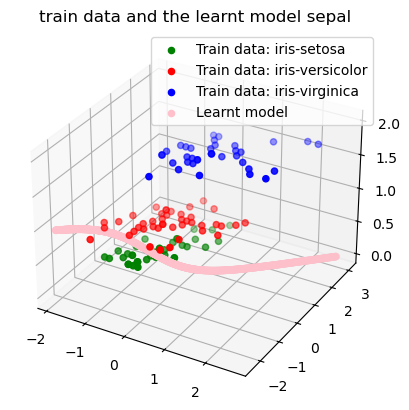

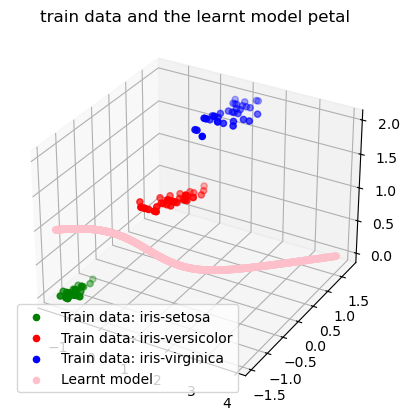

In [226]:
import numpy as np
from statistics import mean
trainInputs = np.array(trainInputs)
noOfPoints = 1000
xref1 = []
val = min(trainInputs[:, 0])
step1 = (max(trainInputs[:, 0]) - min(trainInputs[:, 0])) / noOfPoints
for _ in range(noOfPoints):
    xref1.append(val)
    val += step1

xref2 = []
val = min(trainInputs[:, 1])
step2 = (max(trainInputs[:, 1]) - min(trainInputs[:, 1])) / noOfPoints
for _ in range(noOfPoints):
    xref2.append(val)
    val += step2

xref3 = []
val = min(trainInputs[:, 2])
step3 = (max(trainInputs[:, 2]) - min(trainInputs[:, 2])) / noOfPoints
for _ in range(noOfPoints):
    xref3.append(val)
    val += step2

xref4 = []
val = min(trainInputs[:, 3])
step2 = (max(trainInputs[:, 3]) - min(trainInputs[:, 3])) / noOfPoints
for _ in range(noOfPoints):
    xref4.append(val)
    val += step2

yref = [1 / (1 + np.exp(-(w0 + w1 * el1 + w2 * el2 + w3 * el3 + w4 * el4))) for el1, el2, el3, el4 in zip(xref1, xref2, xref3, xref4)]

plot3Ddata1(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model sepal',classNames=["iris-setosa","iris-versicolor","iris-virginica"])
plot3Ddata1(feature3train, feature4train, trainOutputs, xref3, xref4, yref, [], [], [], 'train data and the learnt model petal',classNames=["iris-setosa","iris-versicolor","iris-virginica"])



In [227]:
computedTestOutputs = model.predict(testInputs)
computedTestOutputsCross = predictions
from sklearn.metrics import mean_squared_error
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print("Normal")
print('prediction error (manual): ', error)

error = 1 - accuracy

print('prediction error (tool):   ', error)


Normal
prediction error (manual):  0.03333333333333333
prediction error (tool):    0.033333333333333326


In [229]:
ec = 1 / (1 + np.exp(-(w0 + w1 * 5.35 + w2 * 3.85 + w3 * 1.25 + w4 * 0.4)))

print("Rez ec", ec)
if ec >=0 and ec < 0.33:
    print("Iris-setosa")
elif ec >= 0.33 and ec < 0.66:
    print("Iris-versicolor")
else:
    print("Iris-virginica")
print()


Rez ec 0.030674149410691617
Iris-setosa

